### 5.1 Estadística

Desglose del efecto del prompting por región cerebral: para cada ROI con vóxeles en el top 10k ISC, se calcula la RDM cerebral con esos vóxeles y se repite.

In [1]:
import numpy as np, pandas as pd, scipy.io as sio
from scipy.stats import wilcoxon

save_path = 'C:/Users/Ale/'
PROMPTS = ['neutral','literary','cognitive','emotional','syntactic','spatial']

valid = np.load(save_path+'valid_trs.npy'); vidx = np.where(valid)[0]
runs  = sio.loadmat(save_path+'subject_1.mat', squeeze_me=True)['time'][:,1].astype(int)[vidx]
def zvox(Y):
    Y = Y[vidx]; return (Y - Y.mean(0)) / (Y.std(0) + 1e-8)
brain = {s: zvox(np.load(save_path+f'data_subject{s}_isc10k.npy')) for s in range(1,9)}

def unwrap(x):
    while isinstance(x, np.ndarray) and x.size == 1: x = x.item()
    return x
roi_names    = np.array(unwrap(sio.loadmat(save_path+'subject_1.mat',squeeze_me=True)['meta']['ROInumToName']), dtype=object)
top_10k      = np.load(save_path+'isc_mask_indices.npy')
top_10k_rois = np.load(save_path+'voxel_rois.npy')[top_10k]

rois_of_interest = {
 'Temporal_Sup_L':'STG izq. (lenguaje)', 'Temporal_Mid_L':'MTG izq. (semántica)',
 'Frontal_Inf_Oper_L':'IFG Broca (sintaxis)', 'Temporal_Pole_Sup_L':'Polo temporal (narrativa)',
 'Angular_L':'Giro angular (integración)', 'Cingulum_Post_L':'PCC (red por defecto)'}

def rse_folds(Xn, runs):
    F=[]
    for te_run in np.unique(runs):
        te=runs==te_run; tr=~te
        S=Xn[te]@Xn[tr].T; W=np.clip(S,0,None); W=W/(W.sum(1,keepdims=True)+1e-12)
        F.append((te,tr,W))
    return F
def rse_score(F, Y):
    cs=[]
    for te,tr,W in F:
        Yhat=W@Y[tr]; a=Yhat-Yhat.mean(1,keepdims=True); b=Y[te]-Y[te].mean(1,keepdims=True)
        cs.extend((a*b).sum(1)/(np.linalg.norm(a,axis=1)*np.linalg.norm(b,axis=1)+1e-12))
    return np.mean(cs)

rows=[]
for p in PROMPTS:
    X=np.load(save_path+f'fir_matrix_{p}.npy')[vidx]
    Xn=X-X.mean(1,keepdims=True); Xn/=(np.linalg.norm(Xn,axis=1,keepdims=True)+1e-12)
    F=rse_folds(Xn,runs)
    for roi,desc in rois_of_interest.items():
        m=np.where(roi_names==roi)[0]
        if len(m)==0: continue
        rv=np.where(top_10k_rois==m[0]+1)[0]
        if len(rv)<20: continue
        for s in range(1,9):
            rows.append({'roi':desc,'prompt':p,'subject':s,'rse':rse_score(F, brain[s][:,rv])})

dfr=pd.DataFrame(rows); dfr.to_csv(save_path+'rse_encoding_by_roi.csv', index=False)
piv=dfr.groupby(['roi','prompt'])['rse'].mean().unstack()[PROMPTS]
print("RSE medio por ROI × prompt:\n", piv.round(4))
print("\nΔRSE vs neutral (interacción prompt×región):\n", piv.sub(piv['neutral'],axis=0).drop(columns='neutral').round(4))

print("\nWilcoxon por ROI (prompt vs neutral, solo p<0.1):")
for roi in dfr.roi.unique():
    sub=dfr[dfr.roi==roi]
    for p in PROMPTS:
        if p=='neutral': continue
        d=sub[sub.prompt==p].sort_values('subject').rse.values - sub[sub.prompt=='neutral'].sort_values('subject').rse.values
        stat,pv=wilcoxon(d, alternative='greater')
        if pv<0.1: print(f"  {roi} | {p}: ΔRSE={d.mean():+.4f}, p={pv:.4f}")

RSE medio por ROI × prompt:
 prompt                      neutral  literary  cognitive  emotional  \
roi                                                                   
Giro angular (integración)   0.0239    0.0217     0.0234     0.0240   
IFG Broca (sintaxis)        -0.0007   -0.0025    -0.0010    -0.0007   
MTG izq. (semántica)         0.0266    0.0240     0.0262     0.0267   
PCC (red por defecto)       -0.0025   -0.0038    -0.0029    -0.0026   
Polo temporal (narrativa)   -0.0025   -0.0045    -0.0031    -0.0027   
STG izq. (lenguaje)         -0.0002   -0.0017    -0.0003    -0.0001   

prompt                      syntactic  spatial  
roi                                             
Giro angular (integración)     0.0215   0.0238  
IFG Broca (sintaxis)          -0.0023  -0.0008  
MTG izq. (semántica)           0.0241   0.0262  
PCC (red por defecto)         -0.0040  -0.0027  
Polo temporal (narrativa)     -0.0044  -0.0030  
STG izq. (lenguaje)           -0.0016  -0.0003  

ΔRSE vs n

In [4]:
from scipy.stats import wilcoxon
pvals, labels = [], []
for roi in dfr.roi.unique():
    sub = dfr[dfr.roi==roi]
    for p in PROMPTS:
        if p=='neutral': continue
        d = sub[sub.prompt==p].sort_values('subject').rse.values - sub[sub.prompt=='neutral'].sort_values('subject').rse.values
        _, pv = wilcoxon(d, alternative='greater')
        pvals.append(pv); labels.append(f"{roi} | {p}")
pvals = np.array(pvals); n = len(pvals)
oidx = np.argsort(pvals)
q = np.empty(n)
q[oidx] = np.clip(np.minimum.accumulate((pvals[oidx]*n/(np.arange(n)+1))[::-1])[::-1], 0, 1)
print("Wilcoxon con corrección FDR (Benjamini-Hochberg):")
for lab, pv, qq in sorted(zip(labels, pvals, q), key=lambda x: x[2]):
    flag = "  <-- significativo tras FDR" if qq < 0.05 else ""
    print(f"  {lab:34s} p={pv:.3f}  q={qq:.3f}{flag}")

Wilcoxon con corrección FDR (Benjamini-Hochberg):
  STG izq. (lenguaje) | literary     p=1.000  q=1.000
  STG izq. (lenguaje) | cognitive    p=0.926  q=1.000
  STG izq. (lenguaje) | emotional    p=0.039  q=1.000
  STG izq. (lenguaje) | syntactic    p=1.000  q=1.000
  STG izq. (lenguaje) | spatial      p=0.875  q=1.000
  MTG izq. (semántica) | literary    p=1.000  q=1.000
  MTG izq. (semántica) | cognitive   p=0.980  q=1.000
  MTG izq. (semántica) | emotional   p=0.473  q=1.000
  MTG izq. (semántica) | syntactic   p=1.000  q=1.000
  MTG izq. (semántica) | spatial     p=0.973  q=1.000
  IFG Broca (sintaxis) | literary    p=1.000  q=1.000
  IFG Broca (sintaxis) | cognitive   p=0.902  q=1.000
  IFG Broca (sintaxis) | emotional   p=0.727  q=1.000
  IFG Broca (sintaxis) | syntactic   p=1.000  q=1.000
  IFG Broca (sintaxis) | spatial     p=0.844  q=1.000
  Polo temporal (narrativa) | literary p=1.000  q=1.000
  Polo temporal (narrativa) | cognitive p=0.996  q=1.000
  Polo temporal (narrativa)

In [6]:
# Suelo de ruido por permutación
def corr_matrices(F, Y):
    Cs = []
    for te, tr, W in F:
        Yhat = W @ Y[tr]
        A = Yhat - Yhat.mean(1, keepdims=True); A /= (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
        B = Y[te]  - Y[te].mean(1, keepdims=True); B /= (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
        Cs.append(A @ B.T)          # fila = patrón PREDICHO, columna = patrón REAL
    return Cs

NPERM = 2000
rng = np.random.default_rng(0)
Xn0 = np.load(save_path+'fir_matrix_neutral.npy')[vidx]
Xn0 = Xn0 - Xn0.mean(1, keepdims=True); Xn0 /= (np.linalg.norm(Xn0, axis=1, keepdims=True) + 1e-12)
F0 = rse_folds(Xn0, runs)

print("Suelo de ruido por permutación (corregido, condición neutral):")
for roi, desc in rois_of_interest.items():
    m = np.where(roi_names==roi)[0]
    if len(m)==0: continue
    rv = np.where(top_10k_rois==m[0]+1)[0]
    if len(rv)<20: continue
    Cs_subj = [corr_matrices(F0, brain[s][:, rv]) for s in range(1,9)]
    obs = np.mean([np.mean([np.diag(C).mean() for C in Cs]) for Cs in Cs_subj])
    null = np.empty(NPERM)
    for k in range(NPERM):
        vals = []
        for Cs in Cs_subj:
            fm = []
            for C in Cs:
                n = C.shape[0]; sh = rng.integers(1, n)
                fm.append(C[np.arange(n), (np.arange(n)+sh) % n].mean())
            vals.append(np.mean(fm))
        null[k] = np.mean(vals)
    p = (1 + np.sum(null >= obs)) / (NPERM + 1)
    flag = "  <-- significativa" if p < 0.05 else ""
    print(f"  {desc:28s} RSE={obs:+.4f}  p_perm={p:.4f}{flag}")

Suelo de ruido por permutación (corregido, condición neutral):
  STG izq. (lenguaje)          RSE=-0.0007  p_perm=0.0005  <-- significativa
  MTG izq. (semántica)         RSE=+0.0262  p_perm=0.0005  <-- significativa
  IFG Broca (sintaxis)         RSE=-0.0014  p_perm=0.0005  <-- significativa
  Polo temporal (narrativa)    RSE=-0.0030  p_perm=0.0005  <-- significativa
  Giro angular (integración)   RSE=+0.0238  p_perm=0.0005  <-- significativa
  PCC (red por defecto)        RSE=-0.0026  p_perm=0.0005  <-- significativa


In [7]:
from scipy.stats import wilcoxon
print("¿La alineación de cada región es > 0 entre sujetos?")
pv, labs = [], []
for desc in dfr.roi.unique():
    vals = dfr[(dfr.roi==desc) & (dfr.prompt=='neutral')].sort_values('subject').rse.values
    _, p = wilcoxon(vals, alternative='greater')      # H1: la mediana del RSE > 0
    pv.append(p); labs.append((desc, vals.mean()))
pv = np.array(pv); n = len(pv)
o = np.argsort(pv); q = np.empty(n)
q[o] = np.clip(np.minimum.accumulate((pv[o]*n/(np.arange(n)+1))[::-1])[::-1], 0, 1)
for (desc, mean), p, qq in sorted(zip(labs, pv, q), key=lambda x: x[2]):
    flag = "  <-- alineación significativa" if qq < 0.05 else ""
    print(f"  {desc:28s} RSE={mean:+.4f}  p={p:.4f}  q={qq:.4f}{flag}")

¿La alineación de cada región es consistentemente > 0 entre sujetos?
  MTG izq. (semántica)         RSE=+0.0266  p=0.0117  q=0.0586
  Giro angular (integración)   RSE=+0.0239  p=0.0195  q=0.0586
  STG izq. (lenguaje)          RSE=-0.0002  p=0.5273  q=0.7266
  IFG Broca (sintaxis)         RSE=-0.0007  p=0.6289  q=0.7266
  Polo temporal (narrativa)    RSE=-0.0025  p=0.6797  q=0.7266
  PCC (red por defecto)        RSE=-0.0025  p=0.7266  q=0.7266


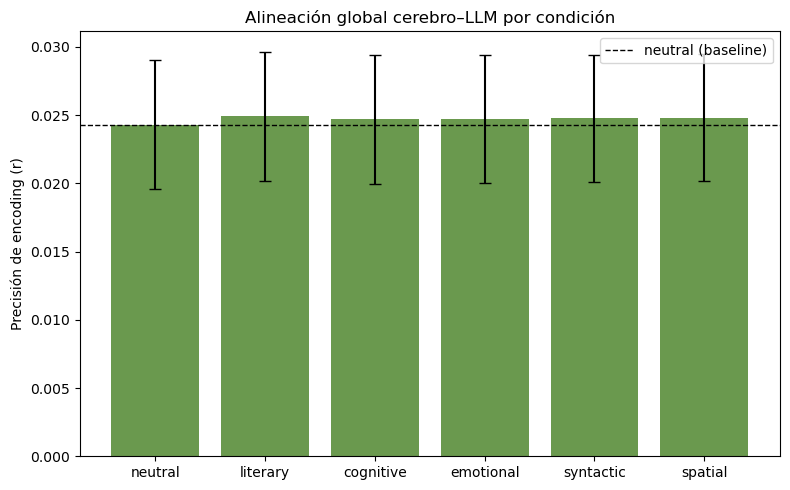

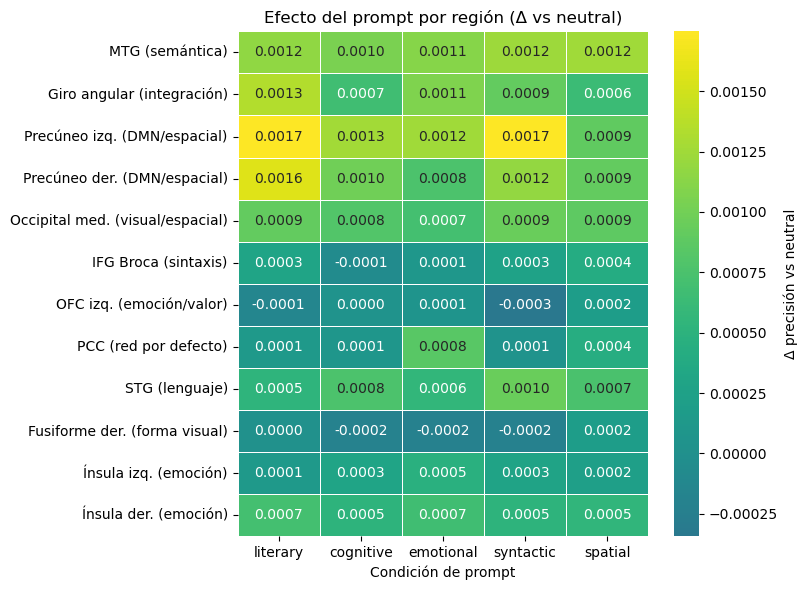

In [22]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
save_path = 'C:/Users/Ale/'
PROMPTS = ['neutral','literary','cognitive','emotional','syntactic','spatial']
dfg = pd.read_csv(save_path+'encoding_global.csv')
dfr = pd.read_csv(save_path+'encoding_roi.csv')

# Figura 1 — alineación global por condición (muestra que el prompt no la cambia)
m = dfg.groupby('prompt')['acc'].mean()[PROMPTS]; e = dfg.groupby('prompt')['acc'].sem()[PROMPTS]
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(PROMPTS, m.values, yerr=e.values, capsize=4, color='#6A994E')
ax.axhline(m['neutral'], color='black', ls='--', lw=1, label='neutral (baseline)')
ax.set_ylabel('Precisión de encoding (r)'); ax.set_title('Alineación global cerebro–LLM por condición'); ax.legend()
plt.tight_layout(); plt.savefig(save_path+'fig_global.png', dpi=300, bbox_inches='tight'); plt.show()

# Figura 2 — efecto del prompt por región (muestra que es minúsculo y no específico)
piv = dfr.groupby(['roi','prompt'])['acc'].mean().unstack()[PROMPTS]
diff = piv.sub(piv['neutral'], axis=0).drop(columns='neutral').loc[mn.index[::-1]]
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(diff, annot=True, fmt='.4f', cmap='viridis', center=0, linewidths=.5,
            cbar_kws={'label':'Δ precisión vs neutral'}, ax=ax)
ax.set_title('Efecto del prompt por región (Δ vs neutral)'); ax.set_xlabel('Condición de prompt'); ax.set_ylabel('')
plt.tight_layout(); plt.savefig(save_path+'fig_prompt_effect.png', dpi=300, bbox_inches='tight'); plt.show()

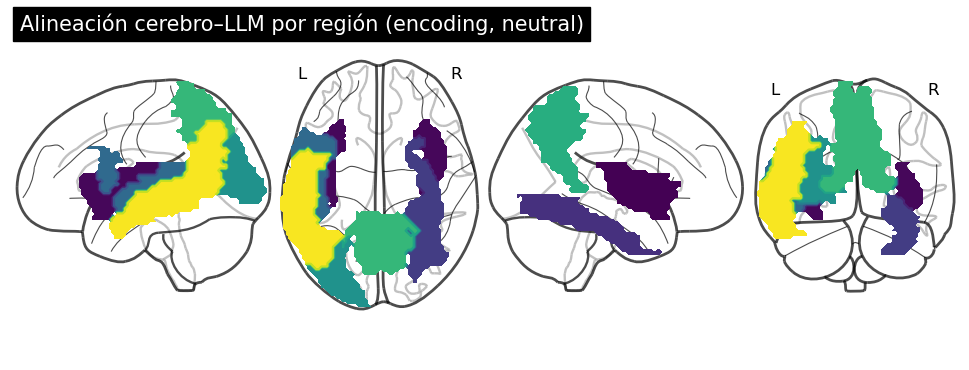

In [37]:
from nilearn.plotting import plot_glass_brain, show

display = plot_glass_brain(None, display_mode="lzry")
# Here, we project statistical maps with filled=True
display.add_contours(out_img, filled=True)
# and add a title
display.title('Alineación cerebro–LLM por región (encoding, neutral)') 

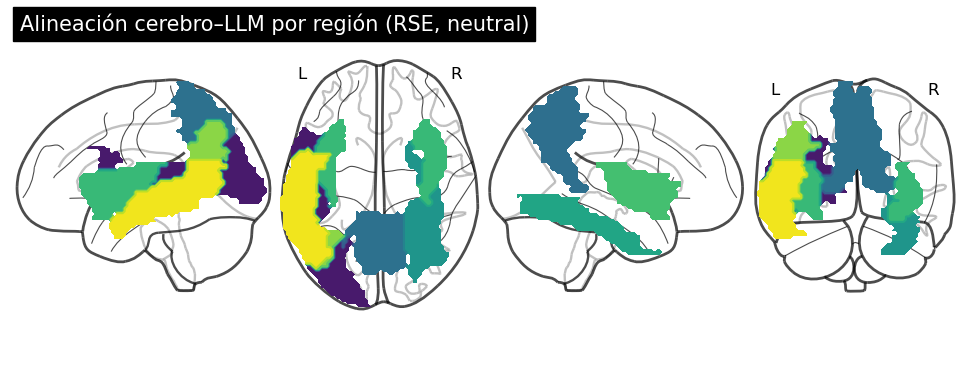

In [45]:
out_img=image.new_img_like(aal_img,out)
display = plot_glass_brain(None, display_mode="lzry")
# Here, we project statistical maps with filled=True
display.add_contours(out_img, filled=True)
# and add a title
display.title('Alineación cerebro–LLM por región (RSE, neutral)') 

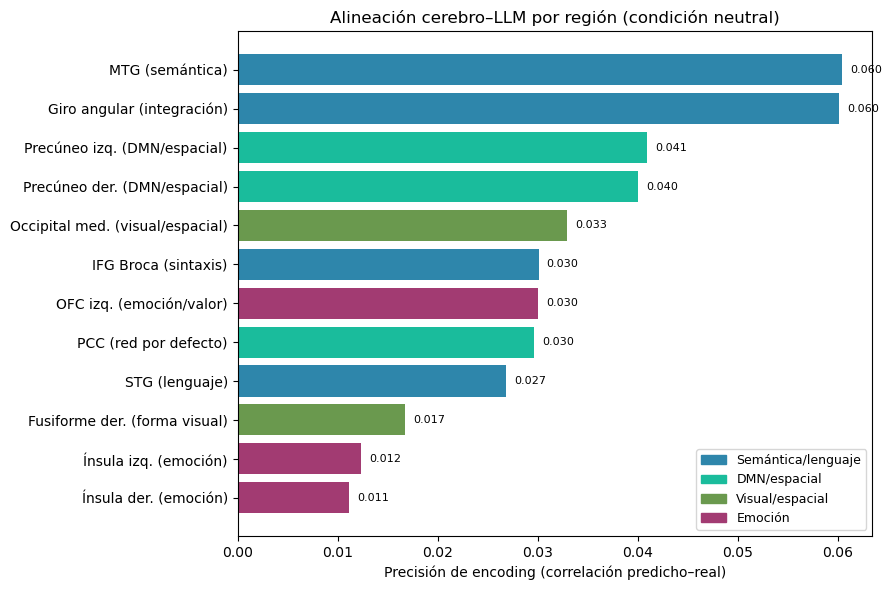

In [27]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
save_path = 'C:/Users/Ale/'
dfr = pd.read_csv(save_path+'encoding_roi.csv')
mn = dfr[dfr.prompt=='neutral'].groupby('roi')['acc'].mean()

cat = {'MTG (semántica)':'Semántica/lenguaje','Giro angular (integración)':'Semántica/lenguaje',
       'IFG Broca (sintaxis)':'Semántica/lenguaje','STG (lenguaje)':'Semántica/lenguaje',
       'Precúneo izq. (DMN/espacial)':'DMN/espacial','Precúneo der. (DMN/espacial)':'DMN/espacial',
       'PCC (red por defecto)':'DMN/espacial','Occipital med. (visual/espacial)':'Visual/espacial',
       'Fusiforme der. (forma visual)':'Visual/espacial','Ínsula izq. (emoción)':'Emoción',
       'Ínsula der. (emoción)':'Emoción','OFC izq. (emoción/valor)':'Emoción'}
col = {'Semántica/lenguaje':'#2E86AB','DMN/espacial':'#1ABC9C','Visual/espacial':'#6A994E','Emoción':'#A23B72'}
mn = mn.sort_values()
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(mn.index, mn.values, color=[col[cat[r]] for r in mn.index])
for i,v in enumerate(mn.values): ax.text(v+0.0008, i, f'{v:.3f}', va='center', fontsize=8)
ax.set_xlabel('Precisión de encoding (correlación predicho–real)')
ax.set_title('Alineación cerebro–LLM por región (condición neutral)')
ax.legend(handles=[Patch(color=c,label=l) for l,c in col.items()], loc='lower right', fontsize=9)
plt.tight_layout(); plt.savefig(save_path+'fig_roi_etiquetada.png', dpi=300, bbox_inches='tight'); plt.show()

In [42]:
import pandas as pd, numpy as np
from scipy.stats import wilcoxon
save_path='C:/Users/Ale/'
dfr=pd.read_csv(save_path+'encoding_roi.csv'); rois=dfr.roi.unique()
pv=[]; mns=[]
for r in rois:
    v=dfr[(dfr.roi==r)&(dfr.prompt=='neutral')].sort_values('subject').acc.values
    _,p=wilcoxon(v, alternative='greater'); pv.append(p); mns.append(v.mean())
pv=np.array(pv); n=len(pv); o=np.argsort(pv); q=np.empty(n)
q[o]=np.clip(np.minimum.accumulate((pv[o]*n/(np.arange(n)+1))[::-1])[::-1],0,1)
print(pd.DataFrame({'region':rois,'precision':np.round(mns,4),'p':np.round(pv,4),'q_FDR':np.round(q,4)}).sort_values('precision',ascending=False).to_string(index=False))

                          region  precision      p  q_FDR
                 MTG (semántica)     0.0604 0.0039 0.0067
      Giro angular (integración)     0.0601 0.0039 0.0067
    Precúneo izq. (DMN/espacial)     0.0409 0.0078 0.0078
    Precúneo der. (DMN/espacial)     0.0400 0.0078 0.0078
Occipital med. (visual/espacial)     0.0329 0.0039 0.0067
            IFG Broca (sintaxis)     0.0301 0.0039 0.0067
        OFC izq. (emoción/valor)     0.0300 0.0039 0.0067
           PCC (red por defecto)     0.0296 0.0078 0.0078
                  STG (lenguaje)     0.0268 0.0039 0.0067
   Fusiforme der. (forma visual)     0.0168 0.0039 0.0067
           Ínsula izq. (emoción)     0.0123 0.0078 0.0078
           Ínsula der. (emoción)     0.0112 0.0078 0.0078
